In [1]:
# ==========================================================
# CELL 1
# Install required libraries for Kaggle
# ==========================================================

print("Starting cell #1")

!pip install -q transformers scikit-learn pandas openpyxl seaborn

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Import all required Python libraries
# ==========================================================
print("Starting cell #2")

import os
import math
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim import AdamW  # Added here (moved from transformers)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("Executed cell #2")


Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #3")

SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed set to: {seed}")

set_seed(SEED)

print("Executed cell #3")

Starting cell #3
Seed set to: 42
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Check whether GPU is available
# ==========================================================

print("Starting cell #4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("Executed cell #4")

Starting cell #4
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Load dataset splits from Kaggle input or working directory
# ==========================================================

print("Starting cell #5")

def find_file(filename):
    search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]
    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return str(matches[0])
    raise FileNotFoundError(f"{filename} not found in /kaggle/input, /kaggle/working, or current directory.")

TRAIN_FILE = find_file("train.csv")
VAL_FILE   = find_file("validation.csv")
TEST_FILE  = find_file("test.csv")

print("Train file:", TRAIN_FILE)
print("Validation file:", VAL_FILE)
print("Test file:", TEST_FILE)

train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nPreview of training data:")
print(train_df.head().to_string(index=False))

print("Executed cell #5")

Starting cell #5
Train file: /kaggle/input/datasets/sajedulislamsajid/dataset/train.csv
Validation file: /kaggle/input/datasets/sajedulislamsajid/dataset/validation.csv
Test file: /kaggle/input/datasets/sajedulislamsajid/dataset/test.csv
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)

Preview of training data:
  Label                                                                                                                                                                                     Bengali                                                                                                                                                                                                   Banglish                                                                                                                                                                                       English
  anger                                                                

In [6]:
# ==========================================================
# UPDATED CELL 6
# Flatten the parallel Bengali, Banglish, and English columns
# into a single text column while preserving language identity.
# ==========================================================

print("Starting updated cell #6")

REQUIRED_TEXT_COLUMNS = ["Bengali", "Banglish", "English"]
LABEL_COLUMN = "Label"
TEXT_COLUMN = "text"
LANG_COLUMN = "language"
SOURCE_ROW_COLUMN = "source_row_id"

missing_cols = [c for c in [LABEL_COLUMN] + REQUIRED_TEXT_COLUMNS if c not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in train_df: {missing_cols}")

def flatten_dataset(df, split_name):
    missing_cols = [c for c in [LABEL_COLUMN] + REQUIRED_TEXT_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{split_name} split is missing columns: {missing_cols}")

    df = df.copy()
    df[SOURCE_ROW_COLUMN] = np.arange(len(df))

    flat_df = df.melt(
        id_vars=[SOURCE_ROW_COLUMN, LABEL_COLUMN],
        value_vars=REQUIRED_TEXT_COLUMNS,
        var_name=LANG_COLUMN,
        value_name=TEXT_COLUMN
    )

    # Remove missing/empty texts before converting to string.
    flat_df = flat_df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
    flat_df[TEXT_COLUMN] = flat_df[TEXT_COLUMN].astype(str).str.strip()
    flat_df = flat_df[flat_df[TEXT_COLUMN] != ""].reset_index(drop=True)

    return flat_df

train_df = flatten_dataset(train_df, "train")
val_df   = flatten_dataset(val_df, "validation")
test_df  = flatten_dataset(test_df, "test")

print(f"New Train shape: {train_df.shape}")
print(f"New Validation shape: {val_df.shape}")
print(f"New Test shape: {test_df.shape}")
print("Columns:", train_df.columns.tolist())

print("\nPreview of flattened training data:")
print(train_df.head().to_string(index=False))

print("Executed updated cell #6")


Starting updated cell #6
New Train shape: (168197, 4)
New Validation shape: (23787, 4)
New Test shape: (48301, 4)
Columns: ['source_row_id', 'Label', 'language', 'text']

Preview of flattened training data:
 source_row_id   Label language                                                                                                                                                                                        text
             0   anger  Bengali                                                                                               মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহলে এই দেশের সকল ফাসি আসামিদের জামিন দিতে হবে।।।
             1     joy  Bengali আলহামদুলিল্লাহ অবশেষে এখান থেকে বেরিয়ে এসে পারছে তার জন্য শুভকামনা নতুন করে এসে ফ্যামিলি কতভাবে সবকিছু একজাস করুক আলহামদুল্লাহ সেটাই সবচেয়ে ভালো হবে ভালো থাকবেন বাপ মার জন্য দোয়া করবেন
             2 disgust  Bengali                                                                                         আপনার উচিত ছি

In [7]:
# ==========================================================
# UPDATED CELL 7
# Convert emotion labels into numerical form and create mappings
# used by evaluation, confusion matrix, and reports.
# ==========================================================

print("Starting updated cell #7")

label_encoder = LabelEncoder()

train_df[LABEL_COLUMN] = label_encoder.fit_transform(train_df[LABEL_COLUMN].astype(str))
val_df[LABEL_COLUMN]   = label_encoder.transform(val_df[LABEL_COLUMN].astype(str))
test_df[LABEL_COLUMN]  = label_encoder.transform(test_df[LABEL_COLUMN].astype(str))

num_labels = len(label_encoder.classes_)

label_mapping = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
label_mapping_inv = {int(idx): label for idx, label in enumerate(label_encoder.classes_)}
target_names = [label_mapping_inv[i] for i in range(num_labels)]

print("Emotion classes:", target_names)
print("Label mapping:", label_mapping)
print("Number of classes:", num_labels)

print("Executed updated cell #7")


Starting updated cell #7
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
Label mapping: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}
Number of classes: 6
Executed updated cell #7


In [8]:
# ==========================================================
# UPDATED CELL 8
# Show the distribution of emotion classes in the training data
# as text output only.
# ==========================================================

print("Starting updated cell #8")

label_counts = (
    train_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
    .rename(index=label_mapping_inv)
)

label_counts_df = (
    label_counts
    .rename("train_samples")
    .reset_index()
    .rename(columns={"index": "emotion_class"})
)

print("Emotion class distribution in training data:")
print(label_counts_df.to_string(index=False))

print("Executed updated cell #8")


Starting updated cell #8
Emotion class distribution in training data:
   Label  train_samples
   anger          31877
 disgust          27505
    fear          15885
     joy          37458
 sadness          34247
surprise          21225
Executed updated cell #8


In [9]:
# ==========================================================
# UPDATED CELL 9
# Compute class weights for imbalanced dataset in label-index order
# ==========================================================

print("Starting updated cell #9")

class_counts_array = (
    train_df[LABEL_COLUMN]
    .value_counts()
    .reindex(range(num_labels), fill_value=0)
    .sort_index()
    .values
)

if np.any(class_counts_array == 0):
    missing = [label_mapping_inv[i] for i, count in enumerate(class_counts_array) if count == 0]
    raise ValueError(f"These classes have zero samples in training data: {missing}")

total_samples = int(class_counts_array.sum())
raw_class_weights = np.sqrt(total_samples / (num_labels * class_counts_array))
class_weights = torch.tensor(raw_class_weights, dtype=torch.float)

print("Class counts ordered by label id:", dict(zip(target_names, class_counts_array.tolist())))
print("Class weights ordered by label id:", dict(zip(target_names, class_weights.tolist())))

print("Executed updated cell #9")


Starting updated cell #9
Class counts ordered by label id: {'anger': 31877, 'disgust': 27505, 'fear': 15885, 'joy': 37458, 'sadness': 34247, 'surprise': 21225}
Class weights ordered by label id: {'anger': 0.9377666115760803, 'disgust': 1.009549617767334, 'fear': 1.3284337520599365, 'joy': 0.8650898337364197, 'sadness': 0.9047367572784424, 'surprise': 1.1492371559143066}
Executed updated cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer for multilingual transformer
# ==========================================================

print("Starting cell #10")

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Executed cell #10


In [11]:
# ==========================================================
# MODIFIED CELL 11
# Simplified Dataset class for flat text data
# ==========================================================

print("Starting modified cell #11")

class EmotionDataset(Dataset):
    def __init__(self, dataframe, text_column, label_column, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.text_column = text_column
        self.label_column = label_column
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = str(row[self.text_column])
        
        encoded = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(row[self.label_column]), dtype=torch.long),
            "sample_idx": torch.tensor(idx, dtype=torch.long)
        }

print("Executed modified cell #11")

Starting modified cell #11
Executed modified cell #11


In [12]:
# ==========================================================
# MODIFIED CELL 12
# Create flat dataset objects
# ==========================================================

print("Starting modified cell #12")

train_dataset = EmotionDataset(train_df, TEXT_COLUMN, LABEL_COLUMN, max_length=MAX_LENGTH)
val_dataset   = EmotionDataset(val_df, TEXT_COLUMN, LABEL_COLUMN, max_length=MAX_LENGTH)
test_dataset  = EmotionDataset(test_df, TEXT_COLUMN, LABEL_COLUMN, max_length=MAX_LENGTH)

print("Train size (flat):", len(train_dataset))
print("Val size (flat):", len(val_dataset))
print("Test size (flat):", len(test_dataset))

print("Executed modified cell #12")

Starting modified cell #12
Train size (flat): 168197
Val size (flat): 23787
Test size (flat): 48301
Executed modified cell #12


In [13]:
# ==========================================================
# UPDATED CELL 13
# Create DataLoaders
# Hybrid strategy:
# 1) Full-coverage shuffled loader for early epochs
# 2) Balanced batch loader for later epochs
# ==========================================================

print("Starting updated cell #13")

NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

CLASSES_PER_BATCH = min(num_labels, 6)
SAMPLES_PER_CLASS = 4
BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS
EVAL_BATCH_SIZE = 32

# Early epochs prioritize full data coverage before stronger contrastive shaping.
FULL_COVERAGE_EPOCHS = 3

train_labels_list = train_df[LABEL_COLUMN].astype(int).tolist()

class BalancedBatchSampler(Sampler):
    def __init__(self, labels, n_classes, n_samples, seed=42):
        self.labels = np.array(labels, dtype=int)
        self.labels_set = sorted(np.unique(self.labels).tolist())
        self.label_to_indices = defaultdict(list)

        for idx, label in enumerate(self.labels):
            self.label_to_indices[int(label)].append(idx)

        self.n_classes = min(int(n_classes), len(self.labels_set))
        self.n_samples = int(n_samples)
        self.batch_size = self.n_classes * self.n_samples
        self.seed = int(seed)
        self.dataset_length = len(self.labels)
        self.num_batches = max(1, self.dataset_length // self.batch_size)
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)

        for _ in range(self.num_batches):
            selected_classes = rng.choice(
                self.labels_set,
                size=self.n_classes,
                replace=False
            )

            batch_indices = []
            for cls in selected_classes:
                cls_indices = self.label_to_indices[int(cls)]
                replace = len(cls_indices) < self.n_samples
                chosen = rng.choice(cls_indices, size=self.n_samples, replace=replace)
                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices

    def __len__(self):
        return self.num_batches

full_coverage_train_loader = DataLoader(
    train_dataset,
    batch_size=BALANCED_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

train_batch_sampler = BalancedBatchSampler(
    labels=train_labels_list,
    n_classes=CLASSES_PER_BATCH,
    n_samples=SAMPLES_PER_CLASS,
    seed=SEED
)

balanced_train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Full coverage epochs:", FULL_COVERAGE_EPOCHS)
print("Balanced batch size:", BALANCED_BATCH_SIZE)
print("Eval batch size:", EVAL_BATCH_SIZE)
print("Classes per balanced batch:", CLASSES_PER_BATCH)
print("Samples per class:", SAMPLES_PER_CLASS)
print("Full coverage train batches:", len(full_coverage_train_loader))
print("Balanced train batches:", len(balanced_train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("Executed updated cell #13")


Starting updated cell #13
Full coverage epochs: 3
Balanced batch size: 24
Eval batch size: 32
Classes per balanced batch: 6
Samples per class: 4
Full coverage train batches: 7009
Balanced train batches: 7008
Validation batches: 744
Test batches: 1510
Executed updated cell #13


In [14]:
# ==========================================================
# MODIFIED CELL 14
# Single-View Multilingual Emotion Model
# Includes AttentionPooling, Shared Encoder, and Projections
# ==========================================================

print("Starting modified cell #14")

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, last_hidden_state, attention_mask):
        # last_hidden_state: [batch_size, seq_len, hidden_size]
        # attention_mask: [batch_size, seq_len]
        
        attn_weights = self.attention(last_hidden_state).squeeze(-1) # [batch_size, seq_len]
        
        # Mask out padding tokens
        if attention_mask is not None:
            attn_weights = attn_weights.masked_fill(attention_mask == 0, float('-inf'))
        
        attn_weights = torch.softmax(attn_weights, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Weighted sum of hidden states
        # [batch_size, 1, seq_len] * [batch_size, seq_len, hidden_size]
        context_vector = torch.bmm(attn_weights.unsqueeze(1), last_hidden_state).squeeze(1)
        return context_vector

class SingleViewEmotionModel(nn.Module):
    def __init__(self, num_labels, model_name="xlm-roberta-base", projection_dim=256, dropout=0.3):
        super().__init__()
        # Load the base encoder
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # We concatenate Mean, Max, and Attention pooling
        self.repr_dim = hidden_size * 3 

        self.attn_pool = AttentionPooling(hidden_size, dropout=dropout)
        self.norm = nn.LayerNorm(self.repr_dim)

        self.projection_head = nn.Sequential(
            nn.Linear(self.repr_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, projection_dim)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.repr_dim),
            nn.Dropout(dropout),
            nn.Linear(self.repr_dim, num_labels)
        )

    def masked_mean_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        summed = torch.sum(last_hidden_state * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def masked_max_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).bool()
        masked_hidden = last_hidden_state.masked_fill(~mask, torch.finfo(last_hidden_state.dtype).min)
        return torch.max(masked_hidden, dim=1).values

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        # Apply the three pooling strategies
        mean_p = self.masked_mean_pool(last_hidden, attention_mask)
        max_p  = self.masked_max_pool(last_hidden, attention_mask)
        attn_p = self.attn_pool(last_hidden, attention_mask)

        # Build combined feature representation
        repr_vec = torch.cat([mean_p, max_p, attn_p], dim=-1)
        repr_vec = self.norm(repr_vec)
        
        logits = self.classifier(repr_vec)
        
        # Projection for Supervised Contrastive Loss
        proj = F.normalize(self.projection_head(repr_vec), dim=-1)

        return {
            "logits": logits,
            "main_logits": logits, 
            "projection": proj
        }

# Initialize the model
model = SingleViewEmotionModel(num_labels=num_labels, model_name=MODEL_NAME)
model = model.to(device)

print("Executed modified cell #14")

Starting modified cell #14


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Executed modified cell #14


In [15]:
# ==========================================================
# CELL 15
# Check CUDA setup
# ==========================================================

print("Starting cell #15")

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("Executed cell #15")

Starting cell #15
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #15


In [16]:
# ==========================================================
# UPDATED CELL 16
# Optimizer, losses, AMP scaler, and scheduler
# Layer-wise learning rates + label smoothing
# ==========================================================

print("Starting updated cell #16")

EPOCHS = 10
WARMUP_RATIO = 0.10
BASE_ENCODER_LR = 1e-5
HEAD_LR = 6e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
BEST_MODEL_MONITOR = "macro_f1"

if FULL_COVERAGE_EPOCHS > EPOCHS:
    raise ValueError("FULL_COVERAGE_EPOCHS cannot be greater than EPOCHS")

model_for_opt = model.module if isinstance(model, nn.DataParallel) else model

lower_encoder_params = []
upper_encoder_params = []

for name, param in model_for_opt.encoder.named_parameters():
    # XLM-R has encoder.layer.0 ... encoder.layer.11
    if any(layer_name in name for layer_name in ["layer.8", "layer.9", "layer.10", "layer.11"]):
        upper_encoder_params.append(param)
    else:
        lower_encoder_params.append(param)

head_params = [
    param for name, param in model_for_opt.named_parameters()
    if not name.startswith("encoder.")
]

optimizer = AdamW(
    [
        {"params": lower_encoder_params, "lr": BASE_ENCODER_LR * 0.65},
        {"params": upper_encoder_params, "lr": BASE_ENCODER_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.05
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

num_full_epochs = FULL_COVERAGE_EPOCHS
num_balanced_epochs = EPOCHS - FULL_COVERAGE_EPOCHS

total_training_steps = (
    len(full_coverage_train_loader) * num_full_epochs
    + len(balanced_train_loader) * num_balanced_epochs
)

warmup_steps = max(1, int(WARMUP_RATIO * total_training_steps))

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("EPOCHS:", EPOCHS)
print("FULL_COVERAGE_EPOCHS:", FULL_COVERAGE_EPOCHS)
print("Balanced epochs:", num_balanced_epochs)
print("Full coverage loader batches:", len(full_coverage_train_loader))
print("Balanced loader batches:", len(balanced_train_loader))
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)

print("Executed updated cell #16")


Starting updated cell #16
EPOCHS: 10
FULL_COVERAGE_EPOCHS: 3
Balanced epochs: 7
Full coverage loader batches: 7009
Balanced loader batches: 7008
Total training steps: 70083
Warmup steps: 7008
Executed updated cell #16


In [17]:
# ==========================================================
# MODIFIED CELL 17
# Supervised Contrastive Loss for single-view training
# ==========================================================

print("Starting modified cell #17")

class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, projections, labels):
        device = projections.device
        batch_size = projections.shape[0]
        
        labels = labels.view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        
        # Mask out self-contrast
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask
        
        logits = torch.matmul(projections, projections.T) / self.temperature
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)
        
        # Mean log-likelihood over positives
        mean_log_prob_pos = (mask * log_prob).sum(1) / torch.clamp(mask.sum(1), min=1e-12)
        
        return -mean_log_prob_pos.mean()

supcon_criterion = SupervisedContrastiveLoss(temperature=0.07)
# Note: Consistency loss is removed as we only have one view per sample
print("Executed modified cell #17")

Starting modified cell #17
Executed modified cell #17


In [18]:
# ==========================================================
# UPDATED CELL 18
# Training epoch for flat single-view data
# Returns correctly named losses for paper-ready logs.
# ==========================================================

print("Starting updated cell #18")

def train_epoch(epoch_num):
    model.train()
    total_loss, total_ce, total_scl = 0.0, 0.0, 0.0

    use_full_coverage = epoch_num <= FULL_COVERAGE_EPOCHS
    current_loader = full_coverage_train_loader if use_full_coverage else balanced_train_loader
    stage_name = "full_coverage" if use_full_coverage else "balanced"

    if (not use_full_coverage) and hasattr(train_batch_sampler, "set_epoch"):
        train_batch_sampler.set_epoch(epoch_num)

    progress_bar = tqdm(current_loader, desc=f"Epoch {epoch_num} [{stage_name}]")

    for batch in progress_bar:
        optimizer.zero_grad(set_to_none=True)

        input_ids = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            outputs = model(input_ids=input_ids, attention_mask=mask)
            logits = outputs["logits"]
            proj = outputs["projection"]

            ce_loss = criterion(logits, labels)
            scl_loss = supcon_criterion(proj, labels)
            loss = ce_loss + 0.1 * scl_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += float(loss.item())
        total_ce += float(ce_loss.item())
        total_scl += float(scl_loss.item())

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "supcon": f"{scl_loss.item():.4f}"
        })

    n_batches = max(1, len(current_loader))
    return {
        "stage_name": stage_name,
        "train_loss": total_loss / n_batches,
        "ce_loss": total_ce / n_batches,
        "supcon_loss": total_scl / n_batches
    }

print("Executed updated cell #18")


Starting updated cell #18
Executed updated cell #18


In [19]:
# ==========================================================
# MODIFIED CELL 19
# Evaluation for single-input model
# ==========================================================

print("Starting modified cell #19")

def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(input_ids, mask)
                logits = outputs["logits"]

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)
    prec, rec, f1_m, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    _, _, f1_w, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)

    return acc, prec, rec, f1_m, f1_w

print("Executed modified cell #19")

Starting modified cell #19
Executed modified cell #19


In [20]:
# ==========================================================
# UPDATED CELL 20
# Kaggle working directory setup
# CSV export is disabled; outputs are printed in notebook cells.
# ==========================================================

print("Starting updated cell #20")

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

print("Kaggle working directory:", WORK_DIR)
print("CSV export is disabled in this notebook.")
print("Only the model checkpoint is saved during training.")
print("Evaluation results are printed directly below each cell.")

print("Executed updated cell #20")


Starting updated cell #20
Kaggle working directory: /kaggle/working
CSV export is disabled in this notebook.
Only the model checkpoint is saved during training.
Evaluation results are printed directly below each cell.
Executed updated cell #20


In [21]:
# ==========================================================
# UPDATED CELL 21
# Training loop with text output only
# Saves only the best model checkpoint; does not create CSV files.
# ==========================================================

print("Starting updated cell #21")

checkpoint_save_dir = "/kaggle/working/emotion_model_checkpoints"
os.makedirs(checkpoint_save_dir, exist_ok=True)

MODEL_CHECKPOINT_NAME = "best_climed_single_view_model.pt"
checkpoint_path = os.path.join(checkpoint_save_dir, MODEL_CHECKPOINT_NAME)

best_val_f1 = -1.0
best_checkpoint_epoch = -1
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{EPOCHS} =====")

    train_stats = train_epoch(epoch)
    val_acc, val_prec, val_rec, val_f1_macro, val_f1_weighted = evaluate(val_loader)

    epoch_record = {
        "epoch": epoch,
        "training_stage": train_stats["stage_name"],
        "train_loss": train_stats["train_loss"],
        "ce_loss": train_stats["ce_loss"],
        "supcon_loss": train_stats["supcon_loss"],
        "val_acc": val_acc,
        "val_prec_macro": val_prec,
        "val_rec_macro": val_rec,
        "val_f1_macro": val_f1_macro,
        "val_f1_weighted": val_f1_weighted
    }
    history.append(epoch_record)

    print(f"Training stage: {train_stats['stage_name']}")
    print(f"Train Loss: {train_stats['train_loss']:.4f}")
    print(f"  CE Loss: {train_stats['ce_loss']:.4f}")
    print(f"  SupCon Loss: {train_stats['supcon_loss']:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation Macro Precision: {val_prec:.4f}")
    print(f"Validation Macro Recall: {val_rec:.4f}")
    print(f"Validation Macro F1: {val_f1_macro:.4f}")
    print(f"Validation Weighted F1: {val_f1_weighted:.4f}")

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_checkpoint_epoch = epoch

        model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": float(best_val_f1),
            "label_classes": list(label_encoder.classes_),
            "label_mapping": label_mapping,
            "model_name": MODEL_NAME,
            "max_length": MAX_LENGTH,
            "num_labels": num_labels,
            "strategy": {
                "input_format": "flat_single_view",
                "languages": REQUIRED_TEXT_COLUMNS,
                "pooling": "mean_max_attention",
                "classification_loss": "weighted_cross_entropy_with_label_smoothing",
                "contrastive_loss": "supervised_contrastive_same_label",
                "contrastive_weight": 0.1,
                "temperature": 0.07
            }
        }

        torch.save(checkpoint, checkpoint_path)
        print(f"Best model checkpoint updated: {checkpoint_path}")

history_df = pd.DataFrame(history)

print("\n===== Training History =====")
print(history_df.to_string(index=False))

print(f"\nTraining complete.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")
print(f"Best checkpoint epoch: {best_checkpoint_epoch}")
print(f"Best checkpoint path: {checkpoint_path}")
print("No CSV files were created.")

print("Executed updated cell #21")


Starting updated cell #21

===== Epoch 1/10 =====


Epoch 1 [full_coverage]:   0%|          | 0/7009 [00:00<?, ?it/s]

/tmp/ipykernel_22/2364882080.py:43: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Training stage: full_coverage
Train Loss: 1.7337
  CE Loss: 1.4372
  SupCon Loss: 2.9643
Validation Accuracy: 0.5552
Validation Macro Precision: 0.5780
Validation Macro Recall: 0.5500
Validation Macro F1: 0.5576
Validation Weighted F1: 0.5574
Best model checkpoint updated: /kaggle/working/emotion_model_checkpoints/best_climed_single_view_model.pt

===== Epoch 2/10 =====


Epoch 2 [full_coverage]:   0%|          | 0/7009 [00:00<?, ?it/s]

...

Training stage: balanced
Train Loss: 0.9097
  CE Loss: 0.6959
  SupCon Loss: 2.1387
Validation Accuracy: 0.6265
Validation Macro Precision: 0.6171
Validation Macro Recall: 0.6314
Validation Macro F1: 0.6218
Validation Weighted F1: 0.6252

===== Epoch 9/10 =====


Epoch 9 [balanced]:   0%|          | 0/7008 [00:00<?, ?it/s]

Training stage: balanced
Train Loss: 0.8741
  CE Loss: 0.6661
  SupCon Loss: 2.0803
Validation Accuracy: 0.6292
Validation Macro Precision: 0.6224
Validation Macro Recall: 0.6339
Validation Macro F1: 0.6267
Validation Weighted F1: 0.6285
Best model checkpoint updated: /kaggle/working/emotion_model_checkpoints/best_climed_single_view_model.pt

===== Epoch 10/10 =====


Epoch 10 [balanced]:   0%|          | 0/7008 [00:00<?, ?it/s]

Training stage: balanced
Train Loss: 0.8535
  CE Loss: 0.6488
  SupCon Loss: 2.0468
Validation Accuracy: 0.6297
Validation Macro Precision: 0.6223
Validation Macro Recall: 0.6332
Validation Macro F1: 0.6266
Validation Weighted F1: 0.6289

===== Training History =====
 epoch training_stage  train_loss  ce_loss  supcon_loss  val_acc  val_prec_macro  val_rec_macro  val_f1_macro  val_f1_weighted
     1  full_coverage    1.733652 1.437222     2.964294 0.555219        0.577978       0.550000      0.557602         0.557411
     2  full_coverage    1.440049 1.162068     2.779809 0.604490        0.605436       0.600410      0.602269         0.604063
     3  full_coverage    1.325598 1.057968     2.676301 0.611973        0.598867       0.618310      0.605378         0.608415
     4       balanced    1.165800 0.915238     2.505620 0.618321        0.616332       0.626667      0.615155         0.615909
     5       balanced    1.079154 0.840250     2.389044 0.623828        0.611934       0.629925  

In [22]:
# ==========================================================
# UPDATED CELL 22
# Evaluate the best model on the test dataset
# Text output only; no CSV file is created.
# ==========================================================

print("Starting updated cell #22")

if os.path.exists(checkpoint_path):
    print(f"Loading best model checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    print(f"Checkpoint epoch: {checkpoint['epoch']}")
    print(f"Best validation Macro F1 from checkpoint: {checkpoint['best_val_f1']:.4f}")
    if "strategy" in checkpoint:
        print("Saved strategy:")
        for key, value in checkpoint["strategy"].items():
            print(f"  {key}: {value}")
else:
    print("Checkpoint not found. Evaluating current in-memory model.")

test_acc, test_prec, test_rec, test_f1_macro, test_f1_weighted = evaluate(test_loader)

test_metrics = {
    "test_accuracy": test_acc,
    "test_macro_precision": test_prec,
    "test_macro_recall": test_rec,
    "test_macro_f1": test_f1_macro,
    "test_weighted_f1": test_f1_weighted
}

print("\n===== Test Set Performance =====")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

print("No CSV files were created.")
print("Executed updated cell #22")


Starting updated cell #22
Loading best model checkpoint: /kaggle/working/emotion_model_checkpoints/best_climed_single_view_model.pt
Checkpoint epoch: 9
Best validation Macro F1 from checkpoint: 0.6267
Saved strategy:
  input_format: flat_single_view
  languages: ['Bengali', 'Banglish', 'English']
  pooling: mean_max_attention
  classification_loss: weighted_cross_entropy_with_label_smoothing
  contrastive_loss: supervised_contrastive_same_label
  contrastive_weight: 0.1
  temperature: 0.07

===== Test Set Performance =====
test_accuracy: 0.6296
test_macro_precision: 0.6234
test_macro_recall: 0.6345
test_macro_f1: 0.6272
test_weighted_f1: 0.6294
No CSV files were created.
Executed updated cell #22


Starting updated cell #23


Generating predictions:   0%|          | 0/1510 [00:00<?, ?it/s]

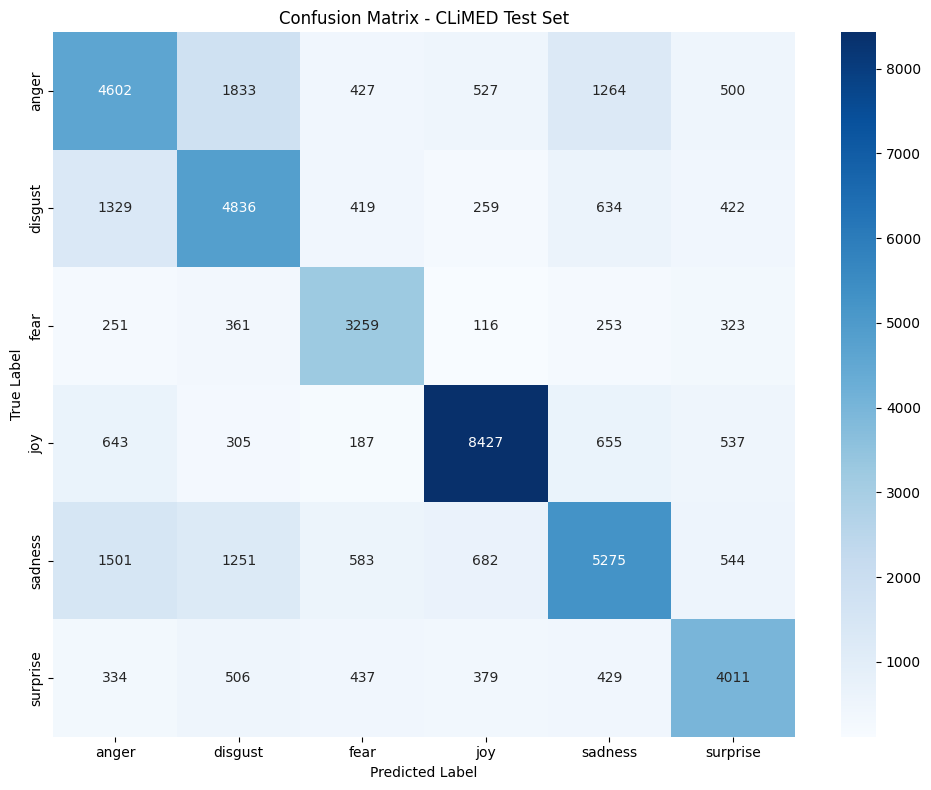


===== Classification Report =====
              precision    recall  f1-score   support

       anger       0.53      0.50      0.52      9153
     disgust       0.53      0.61      0.57      7899
        fear       0.61      0.71      0.66      4563
         joy       0.81      0.78      0.80     10754
     sadness       0.62      0.54      0.58      9836
    surprise       0.63      0.66      0.65      6096

    accuracy                           0.63     48301
   macro avg       0.62      0.63      0.63     48301
weighted avg       0.63      0.63      0.63     48301

One confusion matrix was displayed above.
No CSV, PNG, or prediction export file was created.
Executed updated cell #23


In [23]:
# ==========================================================
# UPDATED CELL 23
# One confusion matrix + classification report
# Text output only; no CSV or prediction file is created.
# ==========================================================

print("Starting updated cell #23")

from sklearn.metrics import confusion_matrix, classification_report

def get_predictions_and_labels(loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Generating predictions"):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(input_ids=input_ids, attention_mask=mask)
                logits = outputs["logits"]

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds)

all_labels, all_preds = get_predictions_and_labels(test_loader)

target_names = [label_mapping_inv[i] for i in range(num_labels)]
ordered_label_ids = list(range(num_labels))

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=ordered_label_ids
)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CLiMED Test Set")
plt.tight_layout()
plt.show()

print("\n===== Classification Report =====")
print(classification_report(
    all_labels,
    all_preds,
    labels=ordered_label_ids,
    target_names=target_names,
    zero_division=0
))

print("One confusion matrix was displayed above.")
print("No CSV, PNG, or prediction export file was created.")
print("Executed updated cell #23")


In [24]:
# ==========================================================
# UPDATED FINAL CELL 24
# Model information and paper-ready summary
# Text output only; no CSV file is created.
# ==========================================================

print("Starting updated cell #24")

model_path = checkpoint_path if "checkpoint_path" in globals() else "/kaggle/working/emotion_model_checkpoints/best_climed_single_view_model.pt"

if os.path.exists(model_path):
    model_size_bytes = os.path.getsize(model_path)
    model_size_mb = model_size_bytes / (1024 * 1024)
else:
    model_size_bytes = 0
    model_size_mb = 0.0

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

summary = {
    "model_name": MODEL_NAME,
    "checkpoint_path": model_path,
    "checkpoint_size_mb": model_size_mb,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "max_length": MAX_LENGTH,
    "num_labels": num_labels,
    "labels": ", ".join(target_names),
    "train_samples_flat": len(train_dataset),
    "validation_samples_flat": len(val_dataset),
    "test_samples_flat": len(test_dataset),
    "best_validation_macro_f1": best_val_f1 if "best_val_f1" in globals() else None,
    "best_checkpoint_epoch": best_checkpoint_epoch if "best_checkpoint_epoch" in globals() else None,
    "test_accuracy": test_metrics.get("test_accuracy") if "test_metrics" in globals() else None,
    "test_macro_precision": test_metrics.get("test_macro_precision") if "test_metrics" in globals() else None,
    "test_macro_recall": test_metrics.get("test_macro_recall") if "test_metrics" in globals() else None,
    "test_macro_f1": test_metrics.get("test_macro_f1") if "test_metrics" in globals() else None,
    "test_weighted_f1": test_metrics.get("test_weighted_f1") if "test_metrics" in globals() else None
}

print("\n================ MODEL INFO ================")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")
print("============================================")

print("No CSV file was created.")
print("Executed updated cell #24")


Starting updated cell #24

================ MODEL INFO ================
model_name: xlm-roberta-base
checkpoint_path: /kaggle/working/emotion_model_checkpoints/best_climed_single_view_model.pt
checkpoint_size_mb: 3203.8826
total_parameters: 280329479
trainable_parameters: 280329479
max_length: 128
num_labels: 6
labels: anger, disgust, fear, joy, sadness, surprise
train_samples_flat: 168197
validation_samples_flat: 23787
test_samples_flat: 48301
best_validation_macro_f1: 0.6267
best_checkpoint_epoch: 9
test_accuracy: 0.6296
test_macro_precision: 0.6234
test_macro_recall: 0.6345
test_macro_f1: 0.6272
test_weighted_f1: 0.6294
No CSV file was created.
Executed updated cell #24
